In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

2025-09-21 20:46:23.630812: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-21 20:46:23.730439: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-21 20:46:26.709925: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
df = pd.read_csv('fruit.csv')
df.head()

,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
0,1,apple,granny_smith,192,8.4,7.3,0.55
1,1,apple,granny_smith,180,8.0,6.8,0.59
2,1,apple,granny_smith,176,7.4,7.2,0.60
3,2,mandarin,mandarin,86,6.2,4.7,0.80
4,2,mandarin,mandarin,84,6.0,4.6,0.79


In [3]:
df['fruit_name'] = df['fruit_name'].str.strip()
df['fruit_subtype'] = df['fruit_subtype'].str.strip()

In [4]:
y = keras.utils.to_categorical(df['fruit_label'])

In [5]:
X = df.drop('fruit_label', axis=1)
X.head()

,fruit_name,fruit_subtype,mass,width,height,color_score
0,apple,granny_smith,192,8.4,7.3,0.55
1,apple,granny_smith,180,8.0,6.8,0.59
2,apple,granny_smith,176,7.4,7.2,0.60
3,mandarin,mandarin,86,6.2,4.7,0.80
4,mandarin,mandarin,84,6.0,4.6,0.79


In [6]:
X = pd.get_dummies(X, prefix='', prefix_sep='')
X.head()

,mass,width,height,color_score,apple,lemon,mandarin,orange,braeburn,cripps_pink,golden_delicious,granny_smith,mandarin,selected_seconds,spanish_belsan,spanish_jumbo,turkey_navel,unknown,urkey_navel
0,192,8.4,7.3,0.55,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False
1,180,8.0,6.8,0.59,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False
2,176,7.4,7.2,0.60,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False
3,86,6.2,4.7,0.80,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False
4,84,6.0,4.6,0.79,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False


In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(47, 19)
(47, 5)
(12, 19)
(12, 5)


In [9]:
from sklearn.preprocessing import StandardScaler

In [10]:
scaler = StandardScaler()
X_train = pd.get_dummies(X_train, prefix='', prefix_sep='')
X_train = scaler.fit_transform(X_train)
X_test = pd.get_dummies(X_test, prefix='', prefix_sep='')
X_test = scaler.transform(X_test)
print(X_train.shape)
print(X_test.shape)

(47, 19)
(12, 19)


In [13]:
model = keras.models.Sequential([
    keras.layers.Dense(len(X_train[0]), activation='relu'),
    keras.layers.Dense(32, activation = 'relu'),
    keras.layers.Dense(10, activation = 'relu'),
    keras.layers.Dense(y.shape[1], activation='softmax')
])

In [14]:
model.compile(optimizer=keras.optimizers.Adam(), loss=keras.losses.CategoricalCrossentropy(), metrics=['accuracy'])

2025-09-21 20:47:07.840258: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [19]:
history = model.fit(X_train, y_train, epochs=30)

Epoch 1/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7447 - loss: 0.7150
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7447 - loss: 0.6895
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7447 - loss: 0.6640
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7447 - loss: 0.6404
Epoch 5/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7447 - loss: 0.6185
Epoch 6/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7447 - loss: 0.5971
Epoch 7/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7447 - loss: 0.5775
Epoch 8/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7447 - loss: 0.5581
Epoch 9/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7447 - loss: 0.5390
Epoch 10/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.7660 - loss: 0.5209
Epoch 11/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7872 - loss: 0.5021
Epoch 12/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7447 - loss: 0.4845
E

In [17]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

KeyError: 'val_accuracy'

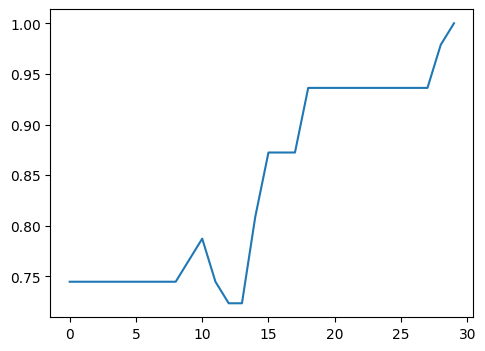

In [20]:
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

Da, model se preprilagodjava jer accuracy dolazi do 100%, to je ocekivano jer je skup za trening jako mali